In [1]:
import time
from time import sleep, monotonic
import datetime
import numpy as np
import matplotlib.pyplot as plt
import sys
import pyvisa
import qcodes as qc
from qcodes.dataset import Measurement
from qcodes.dataset import do0d
from qcodes.dataset.experiment_container import new_experiment, load_experiment_by_name
from qcodes.dataset.plotting import plot_by_id
from qcodes.dataset.data_set import load_by_id, load_by_counter
from qcodes import initialise_or_create_database_at, new_data_set, new_experiment
from qcodes.station import Station
initialise_or_create_database_at("./2026-04-17_SNSPD6.db")
from functions import quick_check
from functions import calibrate
import snspd
params = snspd.snspd('D:\SNSPD\SNSPD2\SNSPD5\snspd6-1.yaml')

# Set up experiment
exp_name = 'SNSPD6'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')

<>:20: SyntaxWarning: invalid escape sequence '\S'
<>:20: SyntaxWarning: invalid escape sequence '\S'
C:\Users\QNL\AppData\Local\Temp\ipykernel_21668\1163135740.py:20: SyntaxWarning: invalid escape sequence '\S'
  params = snspd.snspd('D:\SNSPD\SNSPD2\SNSPD5\snspd6-1.yaml')


Logging hadn't been started.
Activating auto-logging. Current session state plus future input saved.
Filename       : C:\Users\QNL\.qcodes\logs\command_history.log
Mode           : append
Output logging : True
Raw input log  : False
Timestamping   : True
State          : active
Qcodes Logfile : C:\Users\QNL\.qcodes\logs\260421-21668-qcodes.log
Experiment loaded. Last ID no: 30


# Analysis

In [9]:
ID = 1
data = load_by_id(ID).get_parameter_data()
power90 = data['power90']['power90']
power10 = data['power10']['power10']
times = data['times']['times']
attenuation = data['attenuation']['attenuation']


In [10]:
power10

array([6.56862842e-10])

In [11]:
power90

array([0.00482223])

In [2]:
min_id = params.pm100d_calibration_minid
max_id = params.pm100d_calibration_maxid

In [3]:
from ipywidgets import interact, IntSlider


def plot_trace(ID):
    data = load_by_id(ID).get_parameter_data()
    times = data['times']['times']
    power90 = data['power90']['power90']
    plt.plot(times, power90, '.')
    plt.title('Power at 90% port')
    plt.show()

interact(plot_trace, ID=IntSlider(min=min_id, max=max_id, step=1, value=min_id,
                                  continuous_update=False));

interactive(children=(IntSlider(value=2, continuous_update=False, description='ID', max=20, min=2), Output()),…

Text(0.5, 1.0, 'Attenuation')

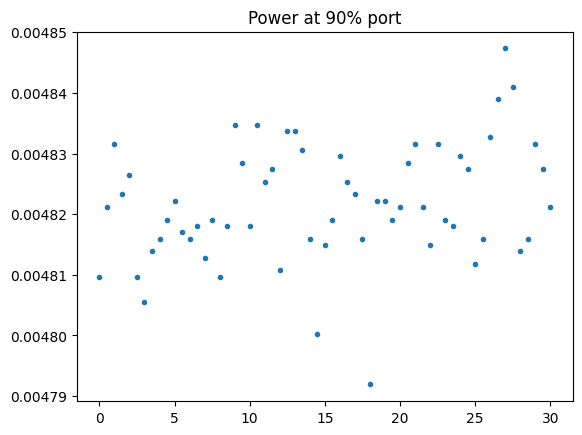

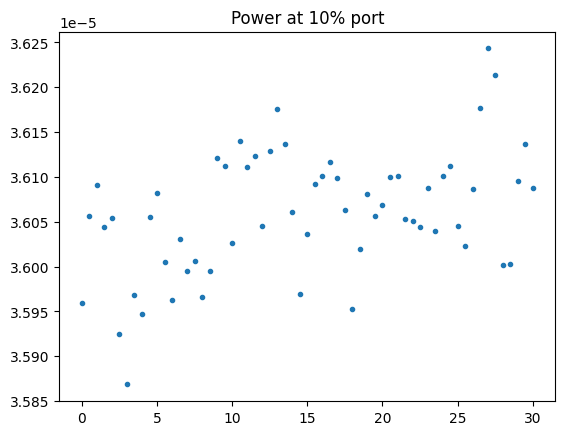

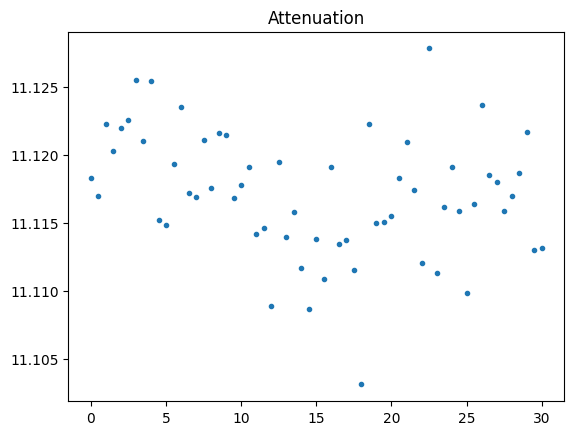

In [13]:
ID = 2
data = load_by_id(ID).get_parameter_data()
power90 = data['power90']['power90']
power10 = data['power10']['power10']
times = data['times']['times']
attenuation = data['attenuation']['attenuation']

plt.plot(times, power90, '.')
plt.title('Power at 90% port')

plt.figure()
plt.plot(times, power10, '.')
plt.title('Power at 10% port')

plt.figure()
plt.plot(times, attenuation, '.')
plt.title('Attenuation')